# Import Necessery Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Better looking plots
plt.style.use('seaborn-v0_8')

pd.set_option('display.float_format', '{:.2f}'.format)

print("Import Successfull")

Import Successfull


# Import Dataframe and Inspect

In [3]:
df = pd.read_csv("crop_yield_dataset.csv")

print("Shape", df.shape)

print(f"Columns ({len(df.columns)}):")
print(df.columns.tolist())
print("\nMissing Values")
print(df.isna().sum())

print("\nData types:")
display(df.dtypes.to_frame(name="dtype"))

display(df.head())
print("\nDescriptive statistics – numeric columns:")
display(df.describe())

Shape (1000, 20)
Columns (20):
['farm_id', 'rainfall_mm', 'avg_temp_c', 'fertilizer_kg_per_ha', 'pesticide_liters', 'sunlight_hours', 'soil_ph', 'farm_size_ha', 'humidity_pct', 'wind_speed_kmh', 'co2_ppm', 'slope_degrees', 'num_harvests_per_year', 'organic_matter_pct', 'pest_pressure_score', 'crop_type', 'soil_type', 'season', 'irrigation_method', 'yield_kg_per_ha']

Missing Values
farm_id                    0
rainfall_mm                0
avg_temp_c                 0
fertilizer_kg_per_ha       0
pesticide_liters           0
sunlight_hours             0
soil_ph                    0
farm_size_ha               0
humidity_pct               0
wind_speed_kmh             0
co2_ppm                    0
slope_degrees              0
num_harvests_per_year      0
organic_matter_pct         0
pest_pressure_score        0
crop_type                  0
soil_type                  0
season                     0
irrigation_method        259
yield_kg_per_ha            0
dtype: int64

Data types:


,dtype
farm_id,object
rainfall_mm,int64
avg_temp_c,float64
fertilizer_kg_per_ha,int64
pesticide_liters,float64
sunlight_hours,float64
soil_ph,float64
farm_size_ha,float64
humidity_pct,float64
wind_speed_kmh,float64


,farm_id,rainfall_mm,avg_temp_c,fertilizer_kg_per_ha,pesticide_liters,sunlight_hours,soil_ph,farm_size_ha,humidity_pct,wind_speed_kmh,co2_ppm,slope_degrees,num_harvests_per_year,organic_matter_pct,pest_pressure_score,crop_type,soil_type,season,irrigation_method,yield_kg_per_ha
0,F0001,320,28.70,18,10.30,4.70,5.40,22.40,31.40,45.60,540,10.00,1,7.90,9.70,Rice,Silty,Summer,Drip,9001.50
1,F0002,241,36.90,43,0.20,10.60,7.30,14.90,44.10,52.00,408,6.00,1,6.40,0.20,Barley,Clay,Spring,NaN,1681.01
2,F0003,609,14.50,134,11.80,8.30,8.30,17.60,82.00,29.80,468,18.80,1,3.20,8.60,Wheat,Loam,Winter,NaN,7638.58
3,F0004,872,31.50,106,2.40,4.30,5.30,32.80,84.00,44.70,394,7.90,3,6.20,9.80,Soybean,Peaty,Spring,Drip,11456.09
4,F0005,163,38.40,293,12.20,12.60,5.30,1.20,64.50,16.90,532,21.60,2,3.50,6.00,Soybean,Silty,Winter,Drip,7424.02



Descriptive statistics – numeric columns:


,rainfall_mm,avg_temp_c,fertilizer_kg_per_ha,pesticide_liters,sunlight_hours,soil_ph,farm_size_ha,humidity_pct,wind_speed_kmh,co2_ppm,slope_degrees,num_harvests_per_year,organic_matter_pct,pest_pressure_score,yield_kg_per_ha
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,806.63,22.11,150.07,10.06,9.08,6.52,25.08,56.90,29.67,467.64,12.23,2.06,4.22,5.01,10929.33
std,409.31,9.82,87.21,5.66,2.84,1.17,14.24,21.50,17.48,48.99,7.15,0.80,2.19,2.83,5062.66
min,100.00,5.00,0.00,0.00,4.00,4.50,0.50,20.00,0.00,380.00,0.00,1.00,0.50,0.00,100.00
25%,457.50,13.80,73.00,5.20,6.67,5.50,13.20,39.18,14.67,427.00,5.97,1.00,2.30,2.60,7423.38
50%,787.50,21.65,153.00,9.90,9.05,6.50,25.10,56.75,29.10,466.00,12.10,2.00,4.10,5.00,10507.26
75%,1171.25,30.60,227.00,15.03,11.50,7.60,37.32,76.12,45.10,509.00,18.50,3.00,6.20,7.40,14154.67
max,1495.00,40.00,300.00,19.90,14.00,8.50,49.90,94.90,60.00,550.00,25.00,3.00,8.00,10.00,26523.43


# Quick look at target distribution

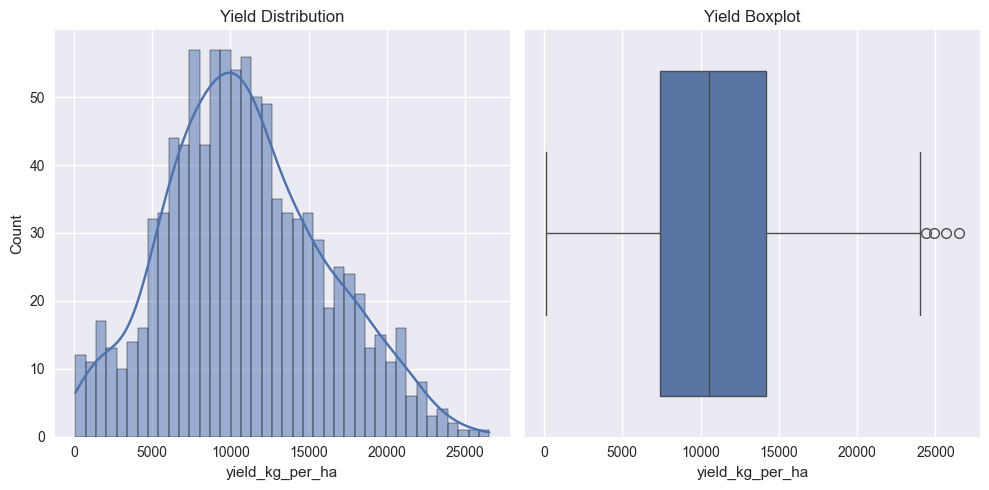

In [4]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
sns.histplot(df['yield_kg_per_ha'], bins = 40, kde=True)
plt.title("Yield Distribution")

plt.subplot(1,2,2)
sns.boxplot(x=df['yield_kg_per_ha'])
plt.title("Yield Boxplot")

plt.tight_layout()
plt.show()

# Detect outliers (using IQR method) for all numeric columns

In [5]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print(f"Numeric columns: {numeric_cols}\n")

# Function to find outliers using IQR
def find_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)][column]
    return outliers, lower_bound, upper_bound

# Dictionary to store results
outlier_summary = {}

print("Outlier detection using IQR method (1.5 × IQR):\n" + "-"*60)

for col in numeric_cols:
    outliers, lb, ub = find_outliers_iqr(df, col)
    outlier_summary[col] = {
        'count': len(outliers),
        'percentage': len(outliers)/len(df)*100,
        'min_outlier': outliers.min() if not outliers.empty else np.nan,
        'max_outlier': outliers.max() if not outliers.empty else np.nan,
        'lower_bound': lb,
        'upper_bound': ub
    }
    
    if len(outliers) > 0:
        print(f"{col:20} → {len(outliers):3d} outliers ({len(outliers)/len(df)*100:.2f}%)")
        print(f"   Range: [{lb:.2f}, {ub:.2f}]")
        print(f"   Extreme values: min={outliers.min():.2f}, max={outliers.max():.2f}")
        print()

# Summary table
summary_df = pd.DataFrame(outlier_summary).T
summary_df = summary_df.round(2)
print("\nOutlier Summary Table:")
display(summary_df)

Numeric columns: ['rainfall_mm', 'avg_temp_c', 'fertilizer_kg_per_ha', 'pesticide_liters', 'sunlight_hours', 'soil_ph', 'farm_size_ha', 'humidity_pct', 'wind_speed_kmh', 'co2_ppm', 'slope_degrees', 'num_harvests_per_year', 'organic_matter_pct', 'pest_pressure_score', 'yield_kg_per_ha']

Outlier detection using IQR method (1.5 × IQR):
------------------------------------------------------------
yield_kg_per_ha      →   4 outliers (0.40%)
   Range: [-2673.55, 24251.60]
   Extreme values: min=24386.00, max=26523.43


Outlier Summary Table:


,count,percentage,min_outlier,max_outlier,lower_bound,upper_bound
rainfall_mm,0.00,0.00,NaN,NaN,-613.12,2241.88
avg_temp_c,0.00,0.00,NaN,NaN,-11.40,55.80
fertilizer_kg_per_ha,0.00,0.00,NaN,NaN,-158.00,458.00
pesticide_liters,0.00,0.00,NaN,NaN,-9.54,29.76
sunlight_hours,0.00,0.00,NaN,NaN,-0.56,18.74
soil_ph,0.00,0.00,NaN,NaN,2.35,10.75
farm_size_ha,0.00,0.00,NaN,NaN,-22.99,73.51
humidity_pct,0.00,0.00,NaN,NaN,-16.25,131.55
wind_speed_kmh,0.00,0.00,NaN,NaN,-30.96,90.74
co2_ppm,0.00,0.00,NaN,NaN,304.00,632.00


# Visualize outliers (boxplots for all numeric columns)

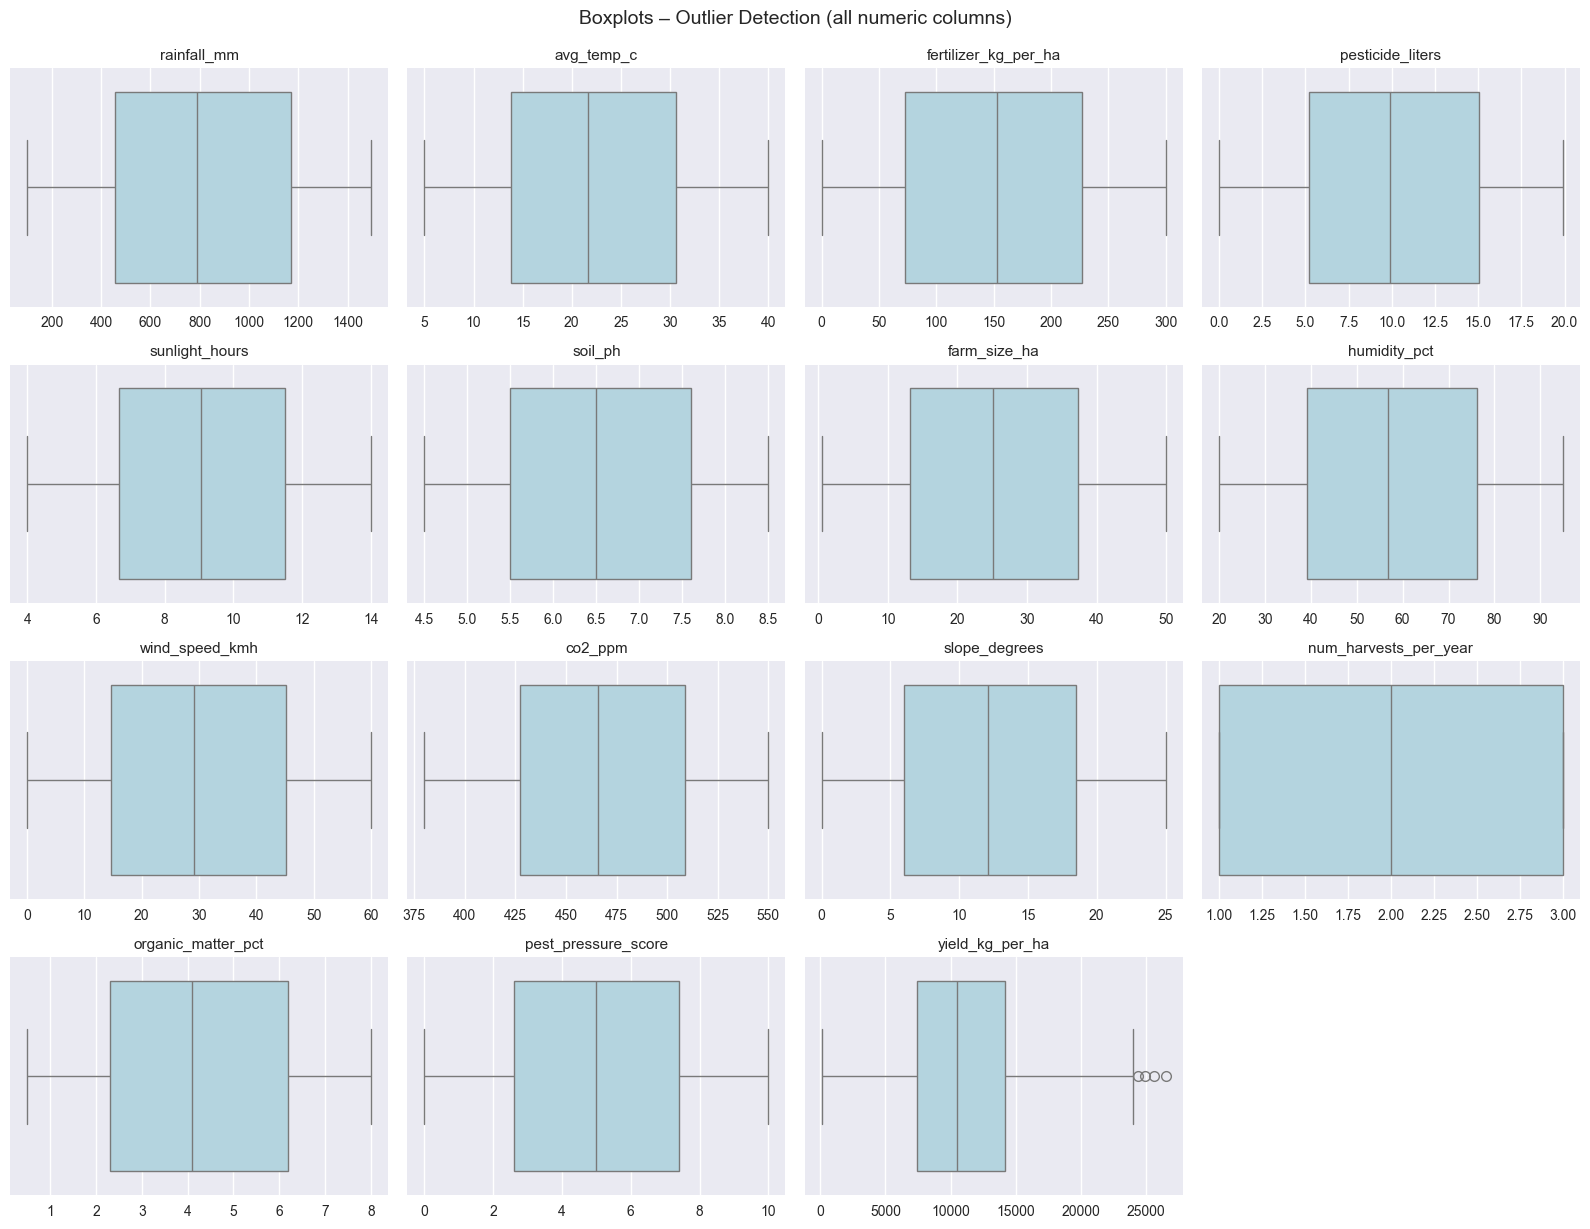

In [6]:
# Create boxplots for all numeric columns
n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4   # adjust layout

plt.figure(figsize=(16, 3*n_rows))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, 4, i)
    sns.boxplot(x=df[col], color='lightblue')
    plt.title(col, fontsize=11)
    plt.xlabel("")

plt.tight_layout()
plt.suptitle("Boxplots – Outlier Detection (all numeric columns)", y=1.02, fontsize=14)
plt.show()

# Cap outliers (winsorization)

In [9]:
# Option B: Cap (winsorize) outliers instead of removing rows
# → values below lower bound → lower bound
# → values above upper bound → upper bound

df_capped = df.copy()

for col in numeric_cols:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # Cap the values
    df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)

print("Outliers have been capped (winsorized).")
print("Original vs capped summary for yield_kg_per_ha:")
print(pd.concat([
    df['yield_kg_per_ha'].describe(),
    df_capped['yield_kg_per_ha'].describe()
], axis=1, keys=['Original', 'Capped']).round(0))

Outliers have been capped (winsorized).
Original vs capped summary for yield_kg_per_ha:
       Original   Capped
count   1000.00  1000.00
mean   10929.00 10925.00
std     5063.00  5050.00
min      100.00   100.00
25%     7423.00  7423.00
50%    10507.00 10507.00
75%    14155.00 14155.00
max    26523.00 24252.00


# Compare boxplots before & after capping

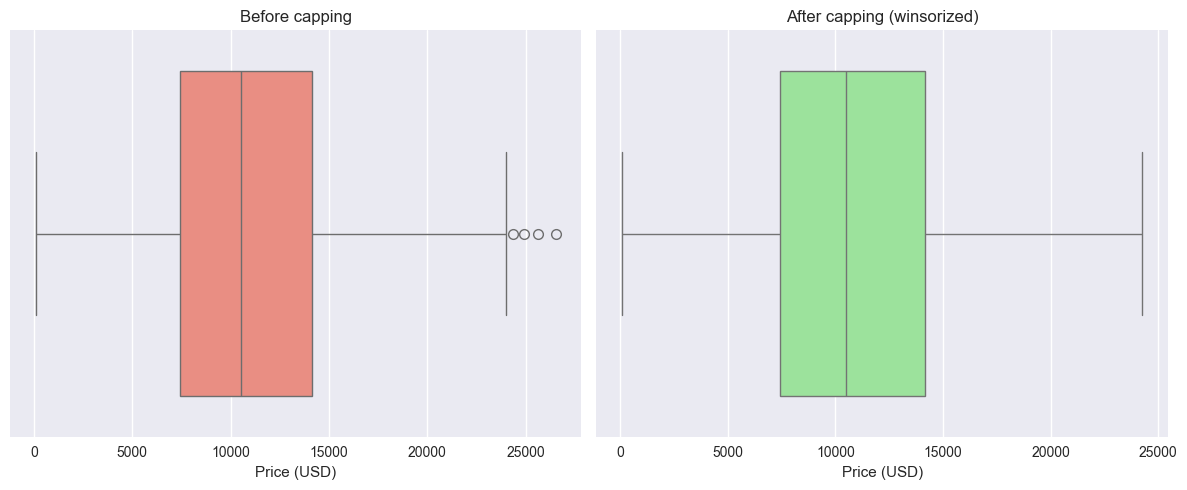

In [10]:
# Visual comparison before vs after capping (only for house_price_usd as example)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df['yield_kg_per_ha'], color='salmon')
plt.title("Before capping")
plt.xlabel("Price (USD)")

plt.subplot(1, 2, 2)
sns.boxplot(x=df_capped['yield_kg_per_ha'], color='lightgreen')
plt.title("After capping (winsorized)")
plt.xlabel("Price (USD)")

plt.tight_layout()
plt.show()

# Prepare features and target

In [11]:
y = df['yield_kg_per_ha']
x = df.drop(['yield_kg_per_ha', 'farm_id' ], axis = 1)

print("Features shape:", x.shape)
print("Target shape:  ", y.shape)

Features shape: (1000, 18)
Target shape:   (1000,)


# Define categorical and numerical columns

In [12]:
features = df.drop(columns = ['yield_kg_per_ha', 'farm_id'], axis = 1)

numeric_features = features.select_dtypes(['number', 'int64', 'float']).columns.tolist()
categorical_features = features.select_dtypes(['category', 'object']).columns.tolist()

print("Numeric Features: ", numeric_features)
print("Categorical Features: ", categorical_features)

Numeric Features:  ['rainfall_mm', 'avg_temp_c', 'fertilizer_kg_per_ha', 'pesticide_liters', 'sunlight_hours', 'soil_ph', 'farm_size_ha', 'humidity_pct', 'wind_speed_kmh', 'co2_ppm', 'slope_degrees', 'num_harvests_per_year', 'organic_matter_pct', 'pest_pressure_score']
Categorical Features:  ['crop_type', 'soil_type', 'season', 'irrigation_method']


# Create preprocessor + polynomial pipeline

In [13]:
deg = 2

# preprocessing process
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop = 'first', sparse_output=False), categorical_features)
    ]
)

print("Preprocessing Done!")

# creating pipeline
model = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=deg, include_bias= False)),
    ('regressor', LinearRegression())
])
model

Preprocessing Done!


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('poly', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

# Train / test split

In [14]:
x_train, x_test, y_train, y_test = train_test_split(
    x,y,
    test_size = 0.2,
    random_state = 42
)

print(f"Train set: {x_train.shape[0]:4d} rows  ({len(x_train)/len(x)*100:.1f}%)")
print(f"Test set : {x_test.shape[0]:4d} rows  ({len(x_test)/len(x)*100:.1f}%)")

Train set:  800 rows  (80.0%)
Test set :  200 rows  (20.0%)


# Train the model

In [15]:
model.fit(x_train, y_train)

print("Model Trained")

Model Trained


# Predictions & evaluation function

In [16]:
y_pred_train = model.predict(x_train)

mae_train = mean_absolute_error(y_train, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
r2_train = r2_score(y_train, y_pred_train)

print("┌────────────────────── TRAIN ──────────────────────┐")
print(f"│ MAE  = {mae_train:10.3f}                                 │")
print(f"│ RMSE = {rmse_train:10.3f}                                 │")
print(f"│ R²   = {r2_train:10.3f}                                 │")
print("└───────────────────────────────────────────────────┘")

y_pred_test = model.predict(x_test)

mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2_test = r2_score(y_test, y_pred_test)

print("┌────────────────────── TEST ───────────────────────┐")
print(f"│ MAE  = {mae_test:10.3f}                                 │")
print(f"│ RMSE = {rmse_test:10.3f}                                 │")
print(f"│ R²   = {r2_test:10.3f}                                 │")
print("└───────────────────────────────────────────────────┘")

┌────────────────────── TRAIN ──────────────────────┐
│ MAE  =    437.190                                 │
│ RMSE =    564.622                                 │
│ R²   =      0.988                                 │
└───────────────────────────────────────────────────┘
┌────────────────────── TEST ───────────────────────┐
│ MAE  =    840.584                                 │
│ RMSE =   1108.288                                 │
│ R²   =      0.952                                 │
└───────────────────────────────────────────────────┘


# Visual comparison (actual vs predicted)

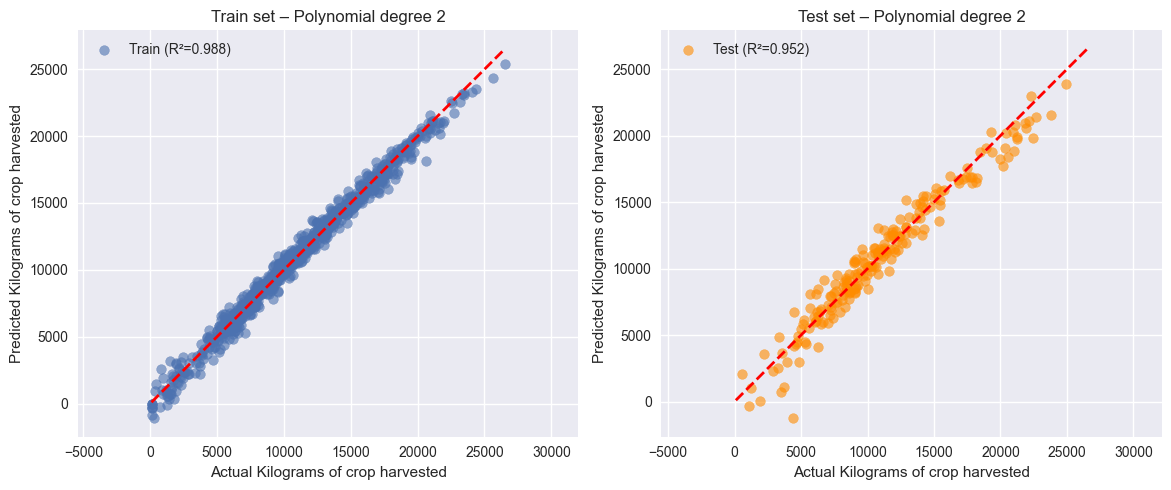

In [17]:
plt.figure(figsize=(12, 5))

# Train
plt.subplot(1,2,1)
plt.scatter(y_train, y_pred_train, alpha=0.6, 
            label=f'Train (R²={r2_score(y_train, y_pred_train):.3f})')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual Kilograms of crop harvested")
plt.ylabel("Predicted Kilograms of crop harvested")
plt.title(f"Train set – Polynomial degree {deg}")
plt.legend()
plt.axis('equal')

# Test
plt.subplot(1,2,2)
plt.scatter(y_test, y_pred_test, alpha=0.6, color='darkorange', 
            label=f'Test (R²={r2_score(y_test, y_pred_test):.3f})')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel("Actual Kilograms of crop harvested")
plt.ylabel("Predicted Kilograms of crop harvested")
plt.title(f"Test set – Polynomial degree {deg}")
plt.legend()
plt.axis('equal')

plt.tight_layout()
plt.show()

# COMPARE POLYNOMIAL DEGREES (1–4)

In [18]:
results = []

for deg in [1, 2, 3, 4]: 
    model = Pipeline([
    ('preprocessor', preprocessor),
    ('poly', PolynomialFeatures(degree=deg, include_bias= False)),
    ('regressor', LinearRegression())
])
    model.fit(x_train, y_train)
    y_pred_train = model.predict(x_train)
    y_pred_test = model.predict(x_test)
    results.append({
        'degree':     deg,
        'R² train':   r2_score(y_train, y_pred_train),
        'R² test':    r2_score(y_test,  y_pred_test),
        'R² diff':    r2_score(y_train, y_pred_train) - r2_score(y_test, y_pred_test),
        'RMSE train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
        'RMSE test':  np.sqrt(mean_squared_error(y_test,  y_pred_test)),
        'RMSE diff':  np.sqrt(mean_squared_error(y_train, y_pred_train)) - 
                      np.sqrt(mean_squared_error(y_test,  y_pred_test))
    })

df_results = pd.DataFrame(results).round(4)
df_results
# #Styled output
# styled = df_results.style\
#     .background_gradient(subset=['R² test'], cmap='RdYlGn')\
#     .background_gradient(subset=['RMSE test'], cmap='YlOrRd_r')\
#     .format({
#         'R² train':   '{:.4f}',
#         'R² test':    '{:.4f}',
#         'R² diff':    '{:+.4f}',
#         'RMSE train': '{:,.0f}',
#         'RMSE test':  '{:,.0f}',
#         'RMSE diff':  '{:+.0f}'
#     })\
#     .highlight_max(subset=['R² test'], color='#dedda')\
#     .highlight_min(subset=['RMSE test'], color='#dedda')

# print("Model comparison across polynomial degrees:")
# display(styled)

,degree,R² train,R² test,R² diff,RMSE train,RMSE test,RMSE diff
0,1,0.65,0.64,0.00,2994.89,3029.47,-34.58
1,2,0.99,0.95,0.04,564.62,1108.29,-543.67
2,3,1.00,0.84,0.16,0.00,2001.69,-2001.69
3,4,1.00,0.81,0.19,0.00,2219.19,-2219.19


# FINAL MODEL WITH BEST DEGREE + VISUALIZATION

Final model (degree 2) performance on test set:
• R²   = 0.9524
• RMSE = 1,108
• MAE  = 841



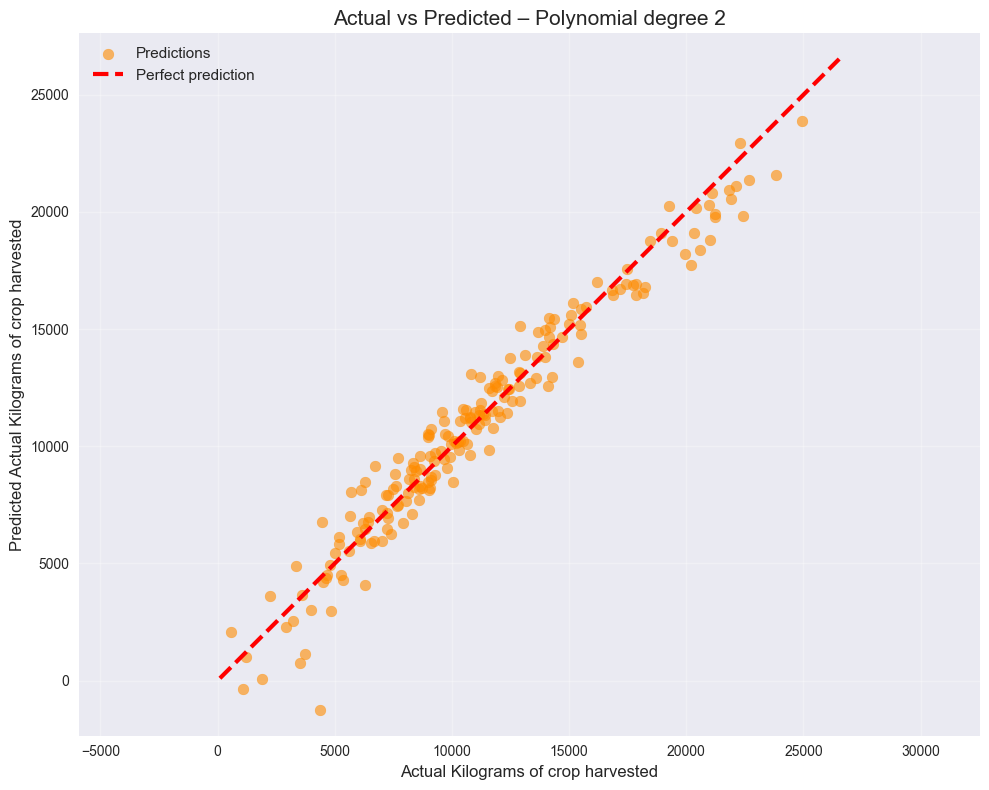

In [26]:
best_degree = df_results.loc[df_results['R² test'].idxmax(), 'degree']

final_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('poly',         PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('model',        LinearRegression())
])

final_pipe.fit(x_train, y_train)

y_pred_test = final_pipe.predict(x_test)

mae   = mean_absolute_error(y_test, y_pred_test)
rmse  = np.sqrt(mean_squared_error(y_test, y_pred_test))
r2    = r2_score(y_test, y_pred_test)

print(f"Final model (degree {best_degree}) performance on test set:")
print(f"• R²   = {r2:.4f}")
print(f"• RMSE = {rmse:,.0f}")
print(f"• MAE  = {mae:,.0f}\n")

# Actual vs Predicted
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred_test, alpha=0.6, s=60, color='darkorange', label='Predictions')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=3, label='Perfect prediction')
plt.xlabel("Actual Kilograms of crop harvested", fontsize=12)
plt.ylabel("Predicted Actual Kilograms of crop harvested", fontsize=12)
plt.title(f"Actual vs Predicted – Polynomial degree {best_degree}", fontsize=15)
plt.legend(fontsize=11)
plt.axis('equal')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# EXAMPLE PREDICTION

In [28]:
ew_farm = pd.DataFrame([{
    'rainfall_mm': 950,
    'avg_temp_c': 24.5,
    'fertilizer_kg_per_ha': 180,
    'pesticide_liters': 8.2,
    'sunlight_hours': 9.1,
    'soil_ph': 6.4,
    'farm_size_ha': 18.7,
    'humidity_pct': 68,
    'wind_speed_kmh': 12.4,
    'co2_ppm': 425,
    'slope_degrees': 4.2,
    'num_harvests_per_year': 2,
    'organic_matter_pct': 4.1,
    'pest_pressure_score': 3.8,
    'crop_type': 'Rice',
    'soil_type': 'Loam',
    'season': 'Summer',
    'irrigation_method': 'Drip'
}])

# Encode same way as training
predicted_Kilograms_of_crop_harvested = final_pipe.predict(ew_farm)[0]

print(f"Predicted Kilograms of crop harvestede: {predicted_Kilograms_of_crop_harvested:,.0f} kg")

Predicted Kilograms of crop harvestede: 24,905 kg
